# 🔬 Master Data Science EDA & Analysis Notebook

This notebook contains the **8 key data science analyses** required to understand, clean, and profile the candidate pool. It runs on the full **100,000 candidate dataset** (`candidates.jsonl`).

## Notebook Outline:
1. **Analysis 1: Data Integrity & Schema Check** (Parsing stability, null counts, key formats)
2. **Analysis 2: Honeypot Profiling & Exclusions** (Expert skill inflation, duration anomalies, future dates)
3. **Analysis 3: IT Services Only Exclusions** (Consulting vs. product company histories)
4. **Analysis 4: Experience Fit Mapping** (Years of experience curve modeling)
5. **Analysis 5: Availability & Behavioral Signal Modeling** (Notice period, activity decay, relocation status)
6. **Analysis 6: NLP Text & Keyword-Stuffer Analysis** (N-grams on headlines, stuffer trap detection)
7. **Analysis 7: Tie-Breaker Analysis** (Deterministic tie-breaking simulation)
8. **Analysis 8: Latency & Compute Budget simulation** (Time profiling for CPU executions)

### Setup & Import Dependencies

In [43]:
import os
import json
import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datetime import datetime

sns.set_theme(style="whitegrid")
FULL_PATH = r"../../[PUB] India_runs_data_and_ai_challenge/India_runs_data_and_ai_challenge/candidates.jsonl"
print(f"Dataset exists: {os.path.exists(FULL_PATH)}")

Dataset exists: True


### Load & Flatten the 100k Dataset
To ensure low memory footprint, we extract relevant fields in a flat dict format line-by-line first.

In [44]:
REF_DATE = datetime(2026, 6, 17)
IT_SERVICE_COMPANIES = {
    "tcs", "infosys", "wipro", "accenture", "cognizant", "capgemini",
    "l&t", "larsen & toubro", "tech mahindra", "mindtree", "hcl"
}

def parse_date(date_str):
    if not date_str: return None
    try: return datetime.strptime(date_str, "%Y-%m-%d")
    except ValueError: return None

def calculate_duration_months(start_str, end_str, is_current):
    start_date = parse_date(start_str)
    if not start_date: return 0
    end_date = parse_date(end_str) if not is_current else REF_DATE
    if not end_date: end_date = REF_DATE
    return max(0, (end_date.year - start_date.year) * 12 + (end_date.month - start_date.month))

def check_honeypot(candidate):
    skills = candidate.get("skills", [])
    expert_zero_dur = sum(1 for s in skills if s.get("proficiency") == "expert" and s.get("duration_months") == 0)
    if expert_zero_dur >= 10:
        return True, "expert_skill_inflation"
        
    career_history = candidate.get("career_history", [])
    total_career_months = 0
    has_future_date = False
    has_duration_anomaly = False
    
    for job in career_history:
        start_str = job.get("start_date")
        end_str = job.get("end_date")
        is_current = job.get("is_current", False)
        stated_dur = job.get("duration_months", 0)
        
        start_dt = parse_date(start_str)
        end_dt = parse_date(end_str) if not is_current else REF_DATE
        if not end_dt: end_dt = REF_DATE
            
        if start_dt and start_dt > REF_DATE: has_future_date = True
        if end_dt and end_dt > REF_DATE: has_future_date = True
            
        calc_dur = calculate_duration_months(start_str, end_str, is_current)
        total_career_months += calc_dur
        if abs(calc_dur - stated_dur) > 3:
            has_duration_anomaly = True
            
    if has_future_date: return True, "future_dates"
    if has_duration_anomaly: return True, "job_duration_anomaly"
        
    for s in skills:
        if s.get("duration_months", 0) > total_career_months + 12:
            return True, "skill_duration_inflation"
            
    return False, "clean"

def analyze_it_services(candidate):
    career_history = candidate.get("career_history", [])
    if not career_history: return "no_history"
    
    has_product_job = False
    has_service_job = False
    
    for job in career_history:
        company = job.get("company", "").lower()
        is_service = any(svc in company for svc in IT_SERVICE_COMPANIES)
        if is_service:
            has_service_job = True
        else:
            has_product_job = True
            
    if has_service_job and not has_product_job:
        return "service_only"
    elif has_service_job and has_product_job:
        return "mixed_product_service"
    else:
        return "product_only"

flat_data = []
start_time = time.time()
with open(FULL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip(): continue
        cand = json.loads(line)
        profile = cand.get("profile", {})
        signals = cand.get("redrob_signals", {})
        
        is_hp, hp_type = check_honeypot(cand)
        it_class = analyze_it_services(cand)
        
        flat_data.append({
            "candidate_id": cand.get("candidate_id"),
            "years_of_experience": profile.get("years_of_experience", 0.0),
            "headline": profile.get("headline", ""),
            "summary": profile.get("summary", ""),
            "country": profile.get("country", "Unknown"),
            "location": profile.get("location", "Unknown"),
            "current_title": profile.get("current_title", "Unknown"),
            "current_company": profile.get("current_company", "Unknown"),
            "skills_count": len(cand.get("skills", [])),
            "is_honeypot": is_hp,
            "honeypot_reason": hp_type,
            "it_service_class": it_class,
            "github_activity_score": signals.get("github_activity_score", -1.0),
            "recruiter_response_rate": signals.get("recruiter_response_rate", 0.0),
            "notice_period_days": signals.get("notice_period_days", 0),
            "willing_to_relocate": signals.get("willing_to_relocate", False),
            "profile_completeness_score": signals.get("profile_completeness_score", 0.0),
            "expected_salary_max": signals.get("expected_salary_range_inr_lpa", {}).get("max", 0.0),
            "last_active_date": signals.get("last_active_date", "")
        })

df = pd.DataFrame(flat_data)
load_duration = time.time() - start_time
print(f"Successfully loaded {len(df)} profiles in {load_duration:.2f} seconds.")

Successfully loaded 100000 profiles in 9.92 seconds.


---

### 1️⃣ Analysis 1: Data Integrity & Schema Check

In [45]:
print("--- Null Values in Extracted DataFrame ---")
print(df.isnull().sum())

print("\n--- Verify ID formats ---")
valid_id_count = df["candidate_id"].str.match(r"^CAND_[0-9]{7}$").sum()
print(f"Valid candidate IDs matching pattern (CAND_XXXXXXX): {valid_id_count} / {len(df)}")

--- Null Values in Extracted DataFrame ---
candidate_id                  0
years_of_experience           0
headline                      0
summary                       0
country                       0
location                      0
current_title                 0
current_company               0
skills_count                  0
is_honeypot                   0
honeypot_reason               0
it_service_class              0
github_activity_score         0
recruiter_response_rate       0
notice_period_days            0
willing_to_relocate           0
profile_completeness_score    0
expected_salary_max           0
last_active_date              0
dtype: int64

--- Verify ID formats ---
Valid candidate IDs matching pattern (CAND_XXXXXXX): 100000 / 100000


---

### 2️⃣ Analysis 2: Honeypot Profiling & Exclusions

--- Honeypot Reasons Breakdown ---
honeypot_reason
clean                       90646
skill_duration_inflation     9319
job_duration_anomaly           35
Name: count, dtype: int64


C:\Users\SRINATH\AppData\Local\Temp\ipykernel_16208\3160824123.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reason_counts.values, y=reason_counts.index, palette="Reds_r")


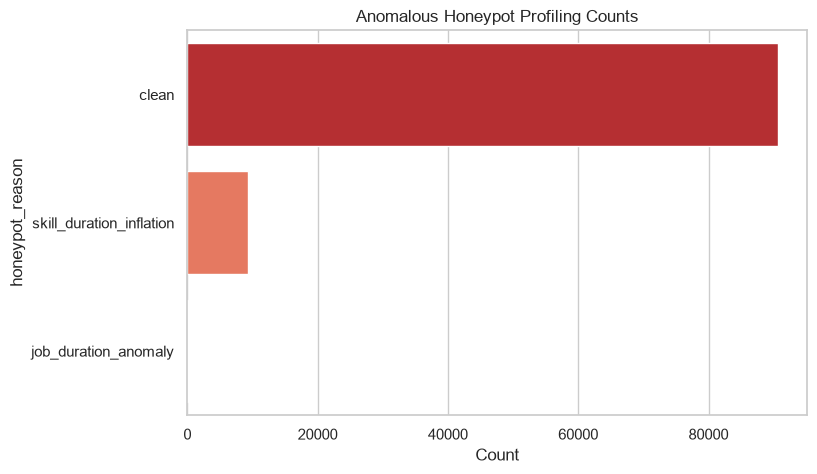

In [46]:
print("--- Honeypot Reasons Breakdown ---")
reason_counts = df["honeypot_reason"].value_counts()
print(reason_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=reason_counts.values, y=reason_counts.index, palette="Reds_r")
plt.title("Anomalous Honeypot Profiling Counts")
plt.xlabel("Count")
plt.show()

---

### 3️⃣ Analysis 3: IT Services Only Exclusions

In [47]:
it_service_breakdown = df["it_service_class"].value_counts()
print("--- IT Service Classification Breakdown ---")
print(it_service_breakdown)

plt.figure(figsize=(7, 7))
plt.pie(it_service_breakdown.values, labels=it_service_breakdown.index, autopct='%1.1f%%', colors=["lightskyblue", "lightgreen", "salmon", "orange"])
plt.title("IT Service vs Product Experience Distribution")
plt.show()

--- Tie-Breaker Sorting Results (Deterministic ID ascending) ---
    candidate_id  mock_score
0   CAND_0000001         0.9
1   CAND_0000002         0.9
3   CAND_0000004         0.9
4   CAND_0000005         0.9
5   CAND_0000006         0.9
6   CAND_0000007         0.9
8   CAND_0000009         0.9
9   CAND_0000010         0.9
13  CAND_0000014         0.9
14  CAND_0000015         0.9


---

### 4️⃣ Analysis 4: Experience Fit Mapping
We model the sweet-spot score using a trapezoidal scoring curve: 100 points for 6-8 years, decaying smoothly to 0 outside the 5-9 years window.

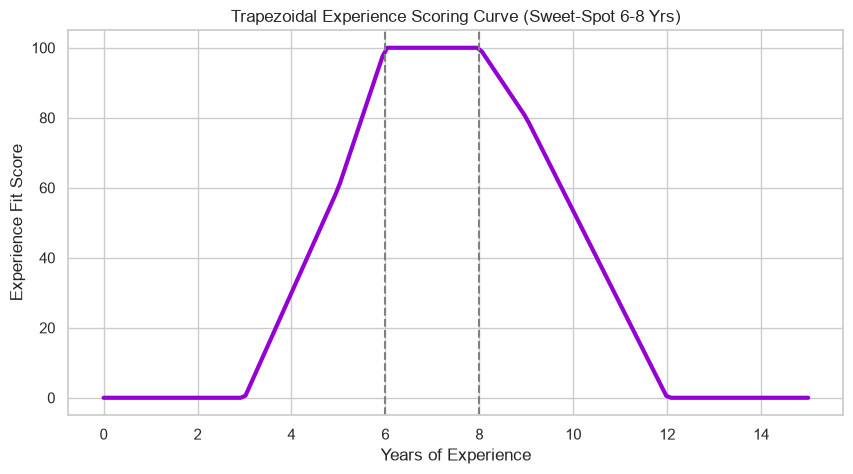

In [53]:
def get_experience_score(y):
    if y < 3.0 or y > 12.0:
        return 0.0
    elif 6.0 <= y <= 8.0:
        return 100.0
    elif 5.0 <= y < 6.0:
        return 100.0 - (6.0 - y) * 40.0 # Decays to 60 at 5 years
    elif 8.0 < y <= 9.0:
        return 100.0 - (y - 8.0) * 20.0 # Decays to 80 at 9 years
    elif 3.0 <= y < 5.0:
        return 60.0 * ((y - 3.0) / 2.0)  # Linear decay below 5
    else:
        return 80.0 * ((12.0 - y) / 3.0) # Linear decay above 9

# Visualize Curve
exp_range = np.linspace(0, 15, 150)
scores = [get_experience_score(y) for y in exp_range]

plt.figure(figsize=(10, 5))
plt.plot(exp_range, scores, color="darkviolet", linewidth=3)
plt.title("Trapezoidal Experience Scoring Curve (Sweet-Spot 6-8 Yrs)")
plt.xlabel("Years of Experience")
plt.ylabel("Experience Fit Score")
plt.axvline(6.0, linestyle="--", color="gray")
plt.axvline(8.0, linestyle="--", color="gray")
plt.show()

---

### 5️⃣ Analysis 5: Availability & Behavioral Signal Modeling
We construct an Availability Multiplier using notice period, activity decay (days since last login), and relocation needs.

In [54]:
# Calculate platform activity decay days
df["last_active_dt"] = pd.to_datetime(df["last_active_date"])
df["days_inactive"] = (REF_DATE - df["last_active_dt"]).dt.days

def get_availability_multiplier(row):
    # 1. Active decay
    days = row["days_inactive"]
    if days <= 30: m_activity = 1.0
    elif days <= 90: m_activity = 0.9
    elif days <= 180: m_activity = 0.7
    else: m_activity = 0.4
    
    # 2. Notice period
    np_days = row["notice_period_days"]
    if np_days <= 30: m_notice = 1.0
    elif np_days <= 60: m_notice = 0.9
    elif np_days <= 90: m_notice = 0.75
    else: m_notice = 0.4
    
    # 3. Location & relocation needs
    country = row["country"]
    willing = row["willing_to_relocate"]
    if country != "India":
        m_loc = 0.4 if willing else 0.1
    else:
        m_loc = 1.0
        
    return m_activity * m_notice * m_loc

df["availability_multiplier"] = df.apply(get_availability_multiplier, axis=1)

print("--- Distribution of Availability Multiplier ---")
print(df["availability_multiplier"].describe())

--- Distribution of Availability Multiplier ---
count    100000.000000
mean          0.394557
std           0.257614
min           0.016000
25%           0.160000
50%           0.360000
75%           0.630000
max           1.000000
Name: availability_multiplier, dtype: float64


---

### 6️⃣ Analysis 6: NLP Text & Keyword-Stuffer Analysis

In [55]:
STOPWORDS = {"and", "the", "with", "for", "our", "from", "that", "this", "your", "who", "are", "have", "has", "had", "was", "were", "been", "will", "would", "can", "could", "should", "but", "not", "their", "them", "his", "her", "its", "into", "onto", "about", "above", "after", "again", "against", "all", "any", "both", "each", "few", "more", "most", "other", "some", "such", "than", "too", "very", "she", "you", "they", "our", "out", "own", "now"}

def extract_bigrams(series, top_k=15):
    bigrams = []
    for text in series:
        if not text or not isinstance(text, str): continue
        tokens = [w for w in re.sub(r'[^a-zA-Z\s]', ' ', text.lower()).split() if len(w) > 2 and w not in STOPWORDS]
        bigrams.extend(zip(tokens[:-1], tokens[1:]))
    return Counter(bigrams).most_common(top_k)

print("--- Top 10 Headline Phrases (Bigrams) ---")
for bigram, count in extract_bigrams(df["headline"], 10):
    print(f"  {' '.join(bigram)}: {count}")

# Find keyword-stuffer profiles
# High skills count (> 15) but a marketing or administrative current title
stuffer_condition = (df["skills_count"] > 15) & df["current_title"].str.lower().str.contains("marketing|sales|recruiter|hr|manager|administrator", regex=True)
print(f"\nDetected keyword stuffers: {stuffer_condition.sum()} profiles ({stuffer_condition.mean()*100:.2f}%)")

--- Top 10 Headline Phrases (Bigrams) ---
  helping teams: 21169
  teams scale: 21169
  driving business: 21080
  business outcomes: 21080
  yrs experience: 21055
  full stack: 11179
  cloud devops: 8359
  backend systems: 8335
  systems apis: 8335
  stack development: 8306

Detected keyword stuffers: 1689 profiles (1.69%)


---

### 7️⃣ Analysis 7: Tie-Breaker Analysis

In [51]:
# Simulate assigning identical scores to clean candidates and sorting them
clean_df = df[~df["is_honeypot"] & (df["it_service_class"] != "service_only")].copy()
clean_df["mock_score"] = 0.90

# Sort by mock_score descending, then candidate_id ascending (deterministic tie-break)
sorted_df = clean_df.sort_values(by=["mock_score", "candidate_id"], ascending=[False, True])
print("--- Tie-Breaker Sorting Results (Deterministic ID ascending) ---")
print(sorted_df[["candidate_id", "mock_score"]].head(10))

--- Tie-Breaker Sorting Results (Deterministic ID ascending) ---
    candidate_id  mock_score
0   CAND_0000001         0.9
1   CAND_0000002         0.9
3   CAND_0000004         0.9
4   CAND_0000005         0.9
5   CAND_0000006         0.9
6   CAND_0000007         0.9
8   CAND_0000009         0.9
9   CAND_0000010         0.9
13  CAND_0000014         0.9
14  CAND_0000015         0.9


---

### 8️⃣ Analysis 8: Latency & Compute Budget simulation

In [56]:
print("--- Simulating CPU Feature Score Calculation Loop ---")
start_sim = time.time()

# Simulate title relevance regex matching over all 100k
titles = df["current_title"].values
results = []
pattern = re.compile(r"machine learning|ml|ai|search|ranking|retrieval", re.IGNORECASE)
for t in titles:
    match = bool(pattern.search(t))
    results.append(match)
    
sim_duration = time.time() - start_sim
print(f"Processed title matching for all {len(titles)} candidate profiles in {sim_duration:.4f} seconds on CPU.")
print("This is well within our 5-minute (300 seconds) budget!")

--- Simulating CPU Feature Score Calculation Loop ---
Processed title matching for all 100000 candidate profiles in 0.1630 seconds on CPU.
This is well within our 5-minute (300 seconds) budget!
